# # Dengue Analysis Pipeline

 This notebook performs exploratory data analysis (EDA) on dengue case data.
 It includes:
 - Data loading and merging
 - Datetime feature engineering
 - Data validation
 - Target distribution analysis
 - Time series visualization
 - Seasonality analysis
 - Correlation analysis
 - Lag feature analysis
 - Rolling average analysis

In [2]:
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

savePlotfile = False

In [3]:
@dataclass
class DengueAnalysisPipeline:
    features_path: str
    labels_path: str

    def load_data(self):

        features = pd.read_csv(self.features_path)
        labels = pd.read_csv(self.labels_path)

        self.df = features.merge(labels, on=["city", "year", "weekofyear"])

        print("Data loaded:")
        print(self.df.shape)

        return self

    def create_datetime(self):

        self.df["date"] = pd.to_datetime(
            self.df["year"].astype(str) + "-01-01"
        ) + pd.to_timedelta((self.df["weekofyear"] - 1) * 7, unit="D")

        self.df = self.df.sort_values(["city", "date"])

        return self

    def validate_data(self):

        print("\nMissing values:")
        print(self.df.isnull().sum().sort_values(ascending=False).head(20))

        print("\nDuplicate rows:")
        print(self.df.duplicated().sum())

        print("\nData types:")
        print(self.df.dtypes)

        return self

    def characterize_target(self):

        print("\nTarget statistics:")
        print(self.df["total_cases"].describe())

        plt.figure(figsize=(10, 5))

        sns.histplot(self.df["total_cases"], bins=50, kde=True)

        plt.title("Distribution of Dengue Cases")

        if savePlotfile:
            plt.savefig("plots/characterize_target.png", dpi=300, bbox_inches="tight")
            plt.close()
        else:
            plt.show()

        return self

    def visualize_time_series(self):

        plt.figure(figsize=(15, 5))

        for city in self.df["city"].unique():
            subset = self.df[self.df["city"] == city]

            plt.plot(subset["date"], subset["total_cases"], label=city)

        plt.legend()
        plt.title("Dengue Cases Over Time")
        plt.xlabel("Date")
        plt.ylabel("Cases")

        if savePlotfile:
            plt.savefig("plots/visualize_time_series.png", dpi=300, bbox_inches="tight")
            plt.close()
        else:
            plt.show()

        return self

    def analyze_seasonality(self):

        seasonal = (
            self.df.groupby(["city", "weekofyear"])["total_cases"].mean().reset_index()
        )

        plt.figure(figsize=(14, 5))

        for city in seasonal["city"].unique():
            subset = seasonal[seasonal["city"] == city]

            plt.plot(subset["weekofyear"], subset["total_cases"], label=city)

        plt.legend()

        plt.title("Seasonal Dengue Patterns")
        plt.xlabel("Week of Year")
        plt.ylabel("Average Cases")

        if savePlotfile:
            plt.savefig("plots/analyze_seasonality.png", dpi=300, bbox_inches="tight")
            plt.close()
        else:
            plt.show()

        return self

    def correlation_analysis(self):

        numeric_df = self.df.select_dtypes(include=np.number)

        corr = numeric_df.corr()

        plt.figure(figsize=(12, 10))

        sns.heatmap(
            corr[["total_cases"]].sort_values(by="total_cases", ascending=False),
            annot=True,
            cmap="coolwarm",
        )

        plt.title("Correlation With Dengue Cases")

        if savePlotfile:
            plt.savefig("plots/correlation_analysis.png", dpi=300, bbox_inches="tight")
            plt.close()
        else:
            plt.show()

        return self

    def lagged_correlation_analysis(self, target="total_cases", max_lag=12):

        import matplotlib.pyplot as plt
        import numpy as np
        import pandas as pd
        import seaborn as sns

        df = self.df.copy()

        # IMPORTANT: enforce correct time order
        df = df.sort_values(["city", "year", "weekofyear"])

        numeric_cols = df.select_dtypes(include=np.number).columns
        numeric_cols = [c for c in numeric_cols if c != target]

        results = []

        for col in numeric_cols:
            for lag in range(max_lag + 1):
                shifted = df.groupby("city")[col].shift(lag)

                valid = pd.concat([shifted, df[target]], axis=1).dropna()

                if len(valid) < 10:
                    corr = np.nan
                else:
                    corr = valid.iloc[:, 0].corr(valid.iloc[:, 1])

                results.append({"feature": col, "lag": lag, "correlation": corr})

        res_df = pd.DataFrame(results)

        # -------------------------
        # PLOT (this was missing!)
        # -------------------------

        pivot = res_df.pivot(index="feature", columns="lag", values="correlation")

        plt.figure(figsize=(14, 8))
        sns.heatmap(pivot, cmap="coolwarm", center=0)

        plt.title("Lagged Correlation with Dengue Cases")
        plt.xlabel("Lag (weeks)")
        plt.ylabel("Feature")

        if savePlotfile:
            plt.savefig(
                "plots/lagged_correlation_analysis.png", dpi=300, bbox_inches="tight"
            )
            plt.close()
        else:
            plt.show()

        return self

    def lag_analysis(self, feature="reanalysis_specific_humidity_g_per_kg", lag=4):

        city_df = self.df[self.df["city"] == "sj"].copy()

        city_df[f"{feature}_lag"] = city_df[feature].shift(lag)

        plt.figure(figsize=(8, 6))

        sns.scatterplot(data=city_df, x=f"{feature}_lag", y="total_cases")

        plt.title(f"{lag}-Week Lag Relationship")

        if savePlotfile:
            plt.savefig("plots/lag_analysis.png", dpi=300, bbox_inches="tight")
            plt.close()
        else:
            plt.show()

        return self

    def rolling_analysis(self):

        city_df = self.df[self.df["city"] == "sj"].copy()

        city_df["temp_roll_4"] = city_df["station_avg_temp_c"].rolling(4).mean()

        plt.figure(figsize=(14, 5))

        plt.plot(city_df["date"], city_df["temp_roll_4"], label="Rolling Temp")

        plt.plot(city_df["date"], city_df["total_cases"], label="Cases")

        plt.legend()

        plt.title("Rolling Temperature vs Cases")

        if savePlotfile:
            plt.savefig("plots/rolling_analysis.png", dpi=300, bbox_inches="tight")
            plt.close()
        else:
            plt.show()

        return self




Data loaded:
(1456, 25)

Missing values:
ndvi_ne                                  194
ndvi_nw                                   52
station_avg_temp_c                        43
station_diur_temp_rng_c                   43
ndvi_sw                                   22
ndvi_se                                   22
station_precip_mm                         22
station_max_temp_c                        20
station_min_temp_c                        14
precipitation_amt_mm                      13
reanalysis_sat_precip_amt_mm              13
reanalysis_specific_humidity_g_per_kg     10
reanalysis_precip_amt_kg_per_m2           10
reanalysis_min_air_temp_k                 10
reanalysis_air_temp_k                     10
reanalysis_relative_humidity_percent      10
reanalysis_max_air_temp_k                 10
reanalysis_avg_temp_k                     10
reanalysis_dew_point_temp_k               10
reanalysis_tdtr_k                         10
dtype: int64

Duplicate rows:
0

Data types:
city          

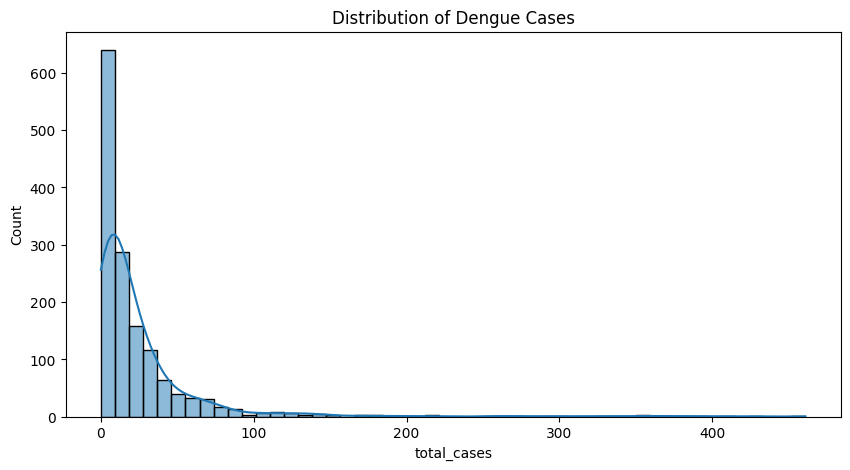

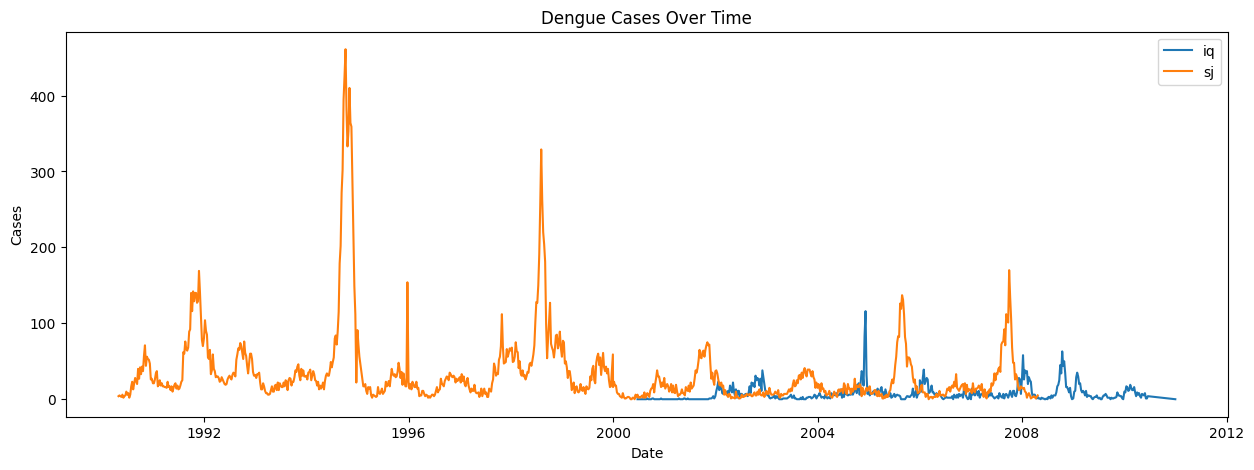

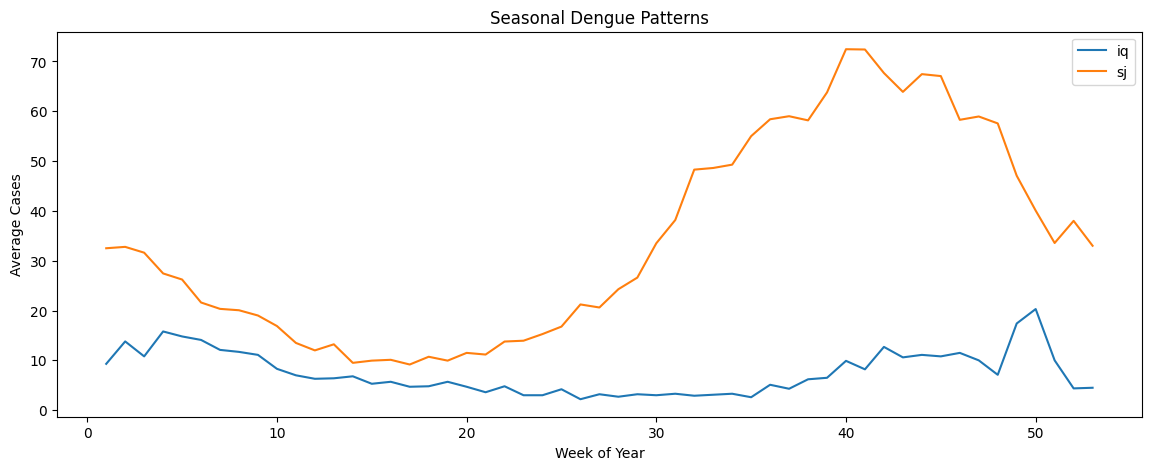

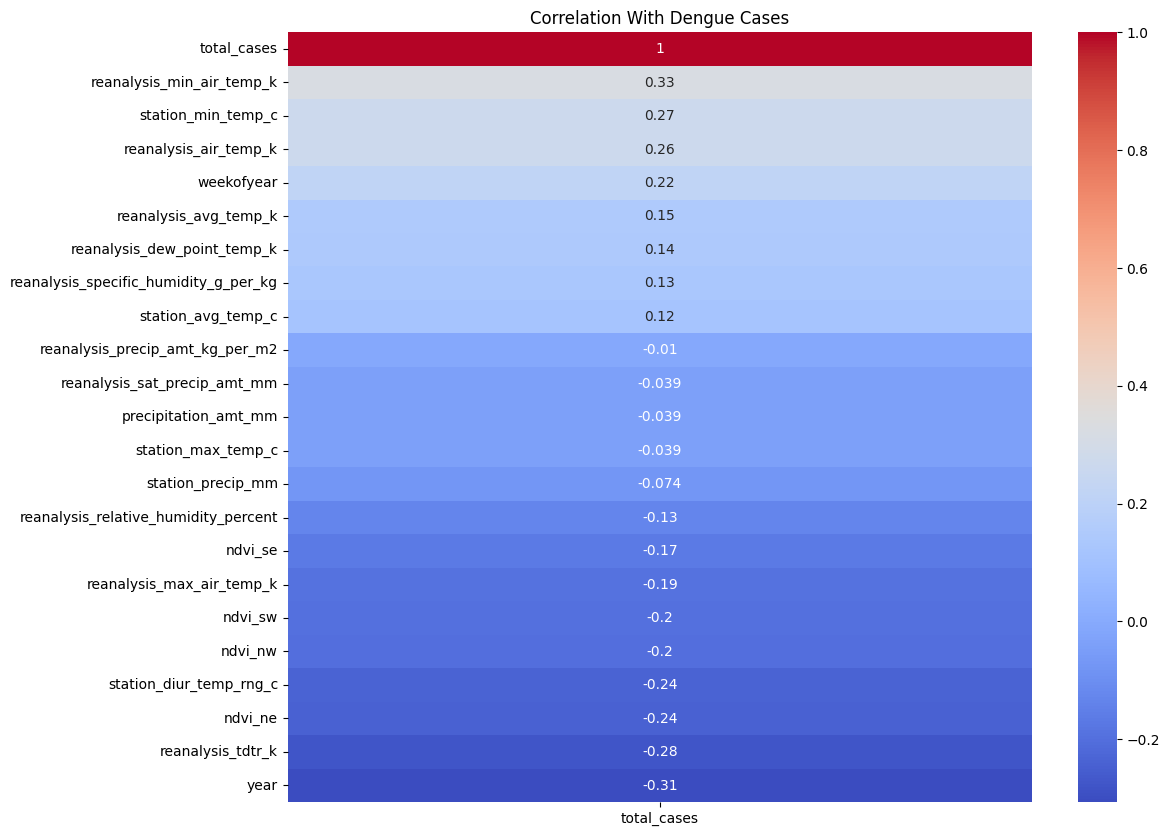

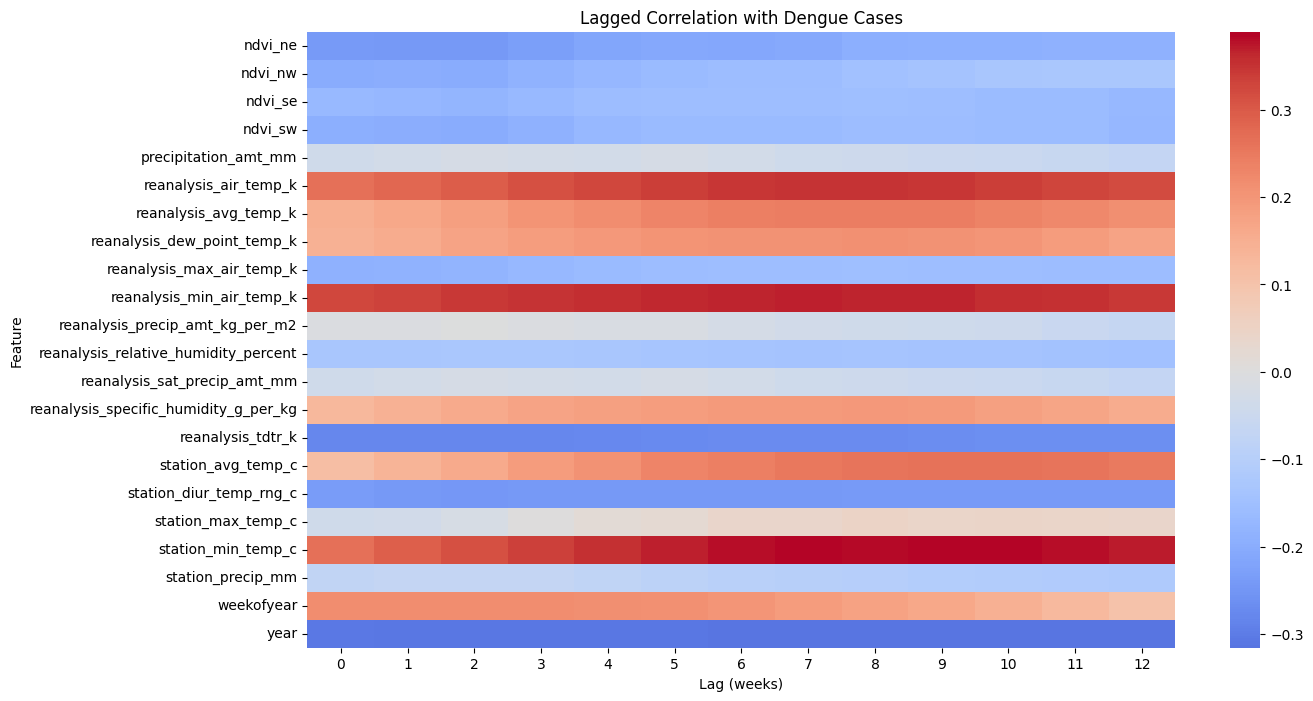

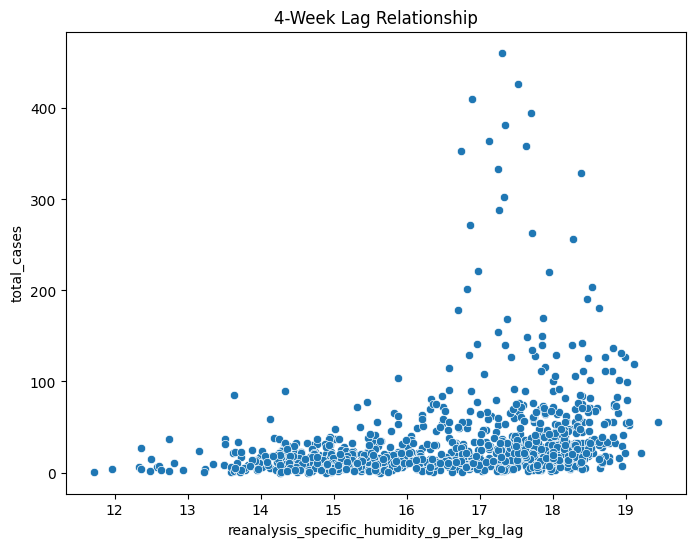

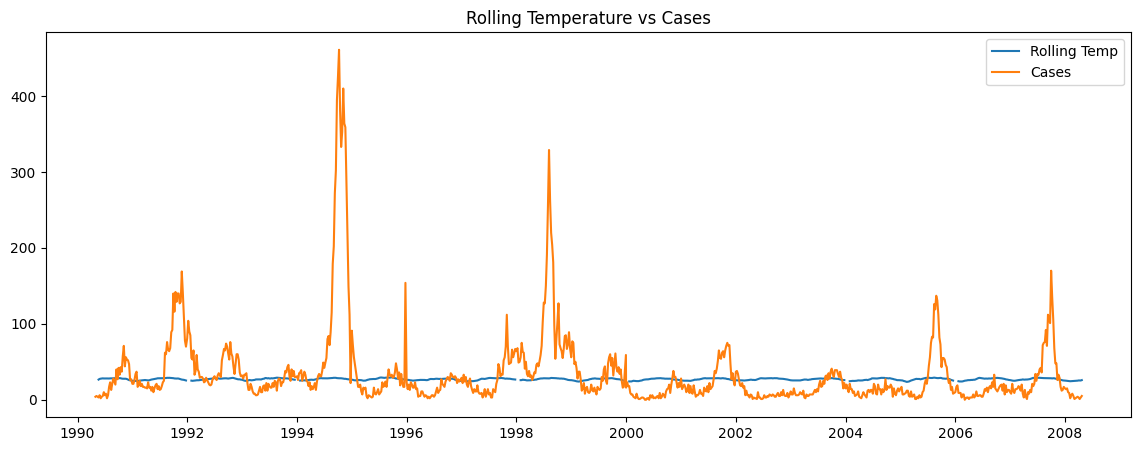

In [4]:
pipeline = (
    DengueAnalysisPipeline(
        features_path="../data/dengue_features_train.csv",
        labels_path="../data/dengue_labels_train.csv",
    )
    .load_data()
    .create_datetime()
    .validate_data()
    .characterize_target()
    .visualize_time_series()
    .analyze_seasonality()
    .correlation_analysis()
    .lagged_correlation_analysis()
    .lag_analysis()
    .rolling_analysis()
)


In [5]:
pipeline

DengueAnalysisPipeline(features_path='../data/dengue_features_train.csv', labels_path='../data/dengue_labels_train.csv')

In [9]:
pipeline.df

,city,year,weekofyear,week_start_date,ndvi_ne,ndvi_nw,ndvi_se,ndvi_sw,precipitation_amt_mm,reanalysis_air_temp_k,...,reanalysis_relative_humidity_percent,reanalysis_sat_precip_amt_mm,reanalysis_specific_humidity_g_per_kg,reanalysis_tdtr_k,station_avg_temp_c,station_diur_temp_rng_c,station_max_temp_c,station_min_temp_c,station_precip_mm,total_cases
0,sj,1990,18,1990-04-30,0.122600,0.103725,0.198483,0.177617,12.42,297.572857,...,73.365714,12.42,14.012857,2.628571,25.442857,6.900000,29.4,20.0,16.0,4
1,sj,1990,19,1990-05-07,0.169900,0.142175,0.162357,0.155486,22.82,298.211429,...,77.368571,22.82,15.372857,2.371429,26.714286,6.371429,31.7,22.2,8.6,5
2,sj,1990,20,1990-05-14,0.032250,0.172967,0.157200,0.170843,34.54,298.781429,...,82.052857,34.54,16.848571,2.300000,26.714286,6.485714,32.2,22.8,41.4,4
3,sj,1990,21,1990-05-21,0.128633,0.245067,0.227557,0.235886,15.36,298.987143,...,80.337143,15.36,16.672857,2.428571,27.471429,6.771429,33.3,23.3,4.0,3
4,sj,1990,22,1990-05-28,0.196200,0.262200,0.251200,0.247340,7.52,299.518571,...,80.460000,7.52,17.210000,3.014286,28.942857,9.371429,35.0,23.9,5.8,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1451,iq,2010,21,2010-05-28,0.342750,0.318900,0.256343,0.292514,55.30,299.334286,...,88.765714,55.30,18.485714,9.800000,28.633333,11.933333,35.4,22.4,27.0,5
1452,iq,2010,22,2010-06-04,0.160157,0.160371,0.136043,0.225657,86.47,298.330000,...,91.600000,86.47,18.070000,7.471429,27.433333,10.500000,34.7,21.7,36.6,8
1453,iq,2010,23,2010-06-11,0.247057,0.146057,0.250357,0.233714,58.94,296.598571,...,94.280000,58.94,17.008571,7.500000,24.400000,6.900000,32.2,19.2,7.4,1
1454,iq,2010,24,2010-06-18,0.333914,0.245771,0.278886,0.325486,59.67,296.345714,...,94.660000,59.67,16.815714,7.871429,25.433333,8.733333,31.2,21.0,16.0,1


In [10]:
pipeline.df.dtypes

city                                         str
year                                       int64
weekofyear                                 int64
week_start_date                              str
ndvi_ne                                  float64
ndvi_nw                                  float64
ndvi_se                                  float64
ndvi_sw                                  float64
precipitation_amt_mm                     float64
reanalysis_air_temp_k                    float64
reanalysis_avg_temp_k                    float64
reanalysis_dew_point_temp_k              float64
reanalysis_max_air_temp_k                float64
reanalysis_min_air_temp_k                float64
reanalysis_precip_amt_kg_per_m2          float64
reanalysis_relative_humidity_percent     float64
reanalysis_sat_precip_amt_mm             float64
reanalysis_specific_humidity_g_per_kg    float64
reanalysis_tdtr_k                        float64
station_avg_temp_c                       float64
station_diur_temp_rn

In [11]:
pipeline.df['week_start_date']

0       1990-04-30
1       1990-05-07
2       1990-05-14
3       1990-05-21
4       1990-05-28
           ...    
1451    2010-05-28
1452    2010-06-04
1453    2010-06-11
1454    2010-06-18
1455    2010-06-25
Name: week_start_date, Length: 1456, dtype: str

In [12]:
import xgboost as xgb
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Load dataset
data = fetch_california_housing()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the scikit-learn integrated XGBoost regressor
model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=6, random_state=42)

model.fit(X_train, y_train)

predictions = model.predict(X_test)
print(f"MSE: {mean_squared_error(y_test, predictions):.4f}")


MSE: 0.2552


In [13]:
num=pipeline.df.select_dtypes(include=np.number)

In [14]:
num.corr()

,year,weekofyear,ndvi_ne,ndvi_nw,ndvi_se,ndvi_sw,precipitation_amt_mm,reanalysis_air_temp_k,reanalysis_avg_temp_k,reanalysis_dew_point_temp_k,...,reanalysis_relative_humidity_percent,reanalysis_sat_precip_amt_mm,reanalysis_specific_humidity_g_per_kg,reanalysis_tdtr_k,station_avg_temp_c,station_diur_temp_rng_c,station_max_temp_c,station_min_temp_c,station_precip_mm,total_cases
year,1.000000,-0.071649,0.223361,0.144345,0.234234,0.277759,0.205302,-0.140016,0.085043,0.132273,...,0.336349,0.205302,0.161596,0.490542,0.047010,0.373644,0.227320,-0.214482,0.219910,-0.306806
weekofyear,-0.071649,1.000000,0.053548,0.048759,0.121557,0.068701,0.118037,0.425753,0.463677,0.348946,...,-0.015191,0.118037,0.350821,0.077933,0.368408,0.023220,0.232098,0.292362,0.066294,0.216452
ndvi_ne,0.223361,0.053548,1.000000,0.850902,0.614380,0.669504,0.205736,-0.340976,-0.037682,0.056077,...,0.457985,0.205736,0.094852,0.673935,0.186227,0.658129,0.491922,-0.315696,0.242263,-0.241376
ndvi_nw,0.144345,0.048759,0.850902,1.000000,0.555809,0.651938,0.193563,-0.317862,-0.030974,0.063289,...,0.449152,0.193563,0.100626,0.645596,0.203975,0.649483,0.490122,-0.304206,0.221314,-0.202235
ndvi_se,0.234234,0.121557,0.614380,0.555809,1.000000,0.820924,0.074633,-0.157447,0.051348,0.002810,...,0.215606,0.074633,0.028795,0.486047,0.089242,0.449599,0.290691,-0.251621,0.131326,-0.168612
ndvi_sw,0.277759,0.068701,0.669504,0.651938,0.820924,1.000000,0.124047,-0.227824,0.022533,0.020746,...,0.311759,0.124047,0.053437,0.569554,0.121060,0.545899,0.377393,-0.294684,0.158345,-0.196461
precipitation_amt_mm,0.205302,0.118037,0.205736,0.193563,0.074633,0.124047,1.000000,-0.017229,0.106384,0.434722,...,0.499984,1.000000,0.451202,0.201427,0.225408,0.193358,0.296215,0.076680,0.486637,-0.038740
reanalysis_air_temp_k,-0.140016,0.425753,-0.340976,-0.317862,-0.157447,-0.227824,-0.017229,1.000000,0.901777,0.529771,...,-0.402338,-0.017229,0.508380,-0.280375,0.619974,-0.261457,0.227768,0.719612,-0.173851,0.264952
reanalysis_avg_temp_k,0.085043,0.463677,-0.037682,-0.030974,0.051348,0.022533,0.106384,0.901777,1.000000,0.614268,...,-0.168371,0.106384,0.612484,0.124200,0.751330,0.107581,0.512220,0.579864,-0.048052,0.151637
reanalysis_dew_point_temp_k,0.132273,0.348946,0.056077,0.063289,0.002810,0.020746,0.434722,0.529771,0.614268,1.000000,...,0.553766,0.434722,0.997051,-0.033512,0.743506,0.037151,0.492319,0.651535,0.241335,0.142531


In [15]:
pipeline.df.head()

,city,year,weekofyear,week_start_date,ndvi_ne,ndvi_nw,ndvi_se,ndvi_sw,precipitation_amt_mm,reanalysis_air_temp_k,...,reanalysis_relative_humidity_percent,reanalysis_sat_precip_amt_mm,reanalysis_specific_humidity_g_per_kg,reanalysis_tdtr_k,station_avg_temp_c,station_diur_temp_rng_c,station_max_temp_c,station_min_temp_c,station_precip_mm,total_cases
0,sj,1990,18,1990-04-30,0.122600,0.103725,0.198483,0.177617,12.42,297.572857,...,73.365714,12.42,14.012857,2.628571,25.442857,6.900000,29.4,20.0,16.0,4
1,sj,1990,19,1990-05-07,0.169900,0.142175,0.162357,0.155486,22.82,298.211429,...,77.368571,22.82,15.372857,2.371429,26.714286,6.371429,31.7,22.2,8.6,5
2,sj,1990,20,1990-05-14,0.032250,0.172967,0.157200,0.170843,34.54,298.781429,...,82.052857,34.54,16.848571,2.300000,26.714286,6.485714,32.2,22.8,41.4,4
3,sj,1990,21,1990-05-21,0.128633,0.245067,0.227557,0.235886,15.36,298.987143,...,80.337143,15.36,16.672857,2.428571,27.471429,6.771429,33.3,23.3,4.0,3
4,sj,1990,22,1990-05-28,0.196200,0.262200,0.251200,0.247340,7.52,299.518571,...,80.460000,7.52,17.210000,3.014286,28.942857,9.371429,35.0,23.9,5.8,6


In [16]:
pipeline.df.columns

Index(['city', 'year', 'weekofyear', 'week_start_date', 'ndvi_ne', 'ndvi_nw',
       'ndvi_se', 'ndvi_sw', 'precipitation_amt_mm', 'reanalysis_air_temp_k',
       'reanalysis_avg_temp_k', 'reanalysis_dew_point_temp_k',
       'reanalysis_max_air_temp_k', 'reanalysis_min_air_temp_k',
       'reanalysis_precip_amt_kg_per_m2',
       'reanalysis_relative_humidity_percent', 'reanalysis_sat_precip_amt_mm',
       'reanalysis_specific_humidity_g_per_kg', 'reanalysis_tdtr_k',
       'station_avg_temp_c', 'station_diur_temp_rng_c', 'station_max_temp_c',
       'station_min_temp_c', 'station_precip_mm', 'total_cases'],
      dtype='str')